In [61]:
import numpy as np
import matplotlib.pyplot as plt
# import mkl

np.random.seed(1234)
# mkl.set_num_threads(2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

## Utility functions

In [62]:
def append_ones(matrix: np.ndarray, axis=1):
    ones = np.ones((matrix.shape[0], 1), dtype=matrix.dtype)
    return np.concatenate((matrix, ones), axis=axis)

## Feed-forward, activations and tiles

In [63]:
# one layer feed forward
def feed_forward(W: np.ndarray, dataset: np.ndarray, activation_fun: callable):
    return activation_fun(dataset @ W)

In [64]:
# sigmoid activation function
def sigmoid(matrix: np.ndarray):
    activations = 1 / (1 + np.exp(-matrix))
    return activations

In [ ]:
# arrange 2D matrices as tiles (takes 4D `examples` tensor with dims: rows x cols x tile_height x tile_width)
def tiles(examples: np.ndarray):
    rows_count, cols_count, tile_height, tile_width = examples.shape

    space_between_tiles = 2
    img_matrix = np.empty(shape=(
        rows_count * (tile_height + space_between_tiles) - space_between_tiles,
        cols_count * (tile_width + space_between_tiles) - space_between_tiles
    ))
    img_matrix.fill(np.nan)

    for y in range(rows_count):
        for x in range(cols_count):
            start_y = y * (tile_height + space_between_tiles)
            start_x = x * (tile_width + space_between_tiles)
            img_matrix[start_y : start_y + tile_height, start_x : start_x + tile_width] = examples[y, x]

    return img_matrix

## Histogram of activations and filters plot

In [66]:
class Rbm:
    def __init__(self, visible_size, hidden_size, learning_rate):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.W = np.random.normal(scale=0.01, size=(visible_size+1, hidden_size+1)).astype(np.float32)
        self.W[:, -1] = 0.0
        self.W[-1, :] = 0.0

In [1]:
import mnists

mnist = mnists.MNIST()

import pickle
import seaborn as sns

with open("./lab1_rbm.pickle.dat", "rb") as f:
    rbm = pickle.load(f)

print(f"rbm.visible_size: {rbm.visible_size}")
print(f"rbm.hidden_size: {rbm.hidden_size}")

ModuleNotFoundError: No module named 'mnists'

In [68]:
DATASET_SIZE = 512
DIGIT_SIZE = 28
mnist_dataset = mnist.test_images().astype(np.float32)
np.random.shuffle(mnist_dataset)
mnist_dataset = np.reshape(mnist_dataset[:DATASET_SIZE] / 255.0, newshape=(DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))

mnist_dataset = append_ones(mnist_dataset)

C:\Users\User\AppData\Local\Temp\ipykernel_23592\1140676621.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mean_activations, bins=50)


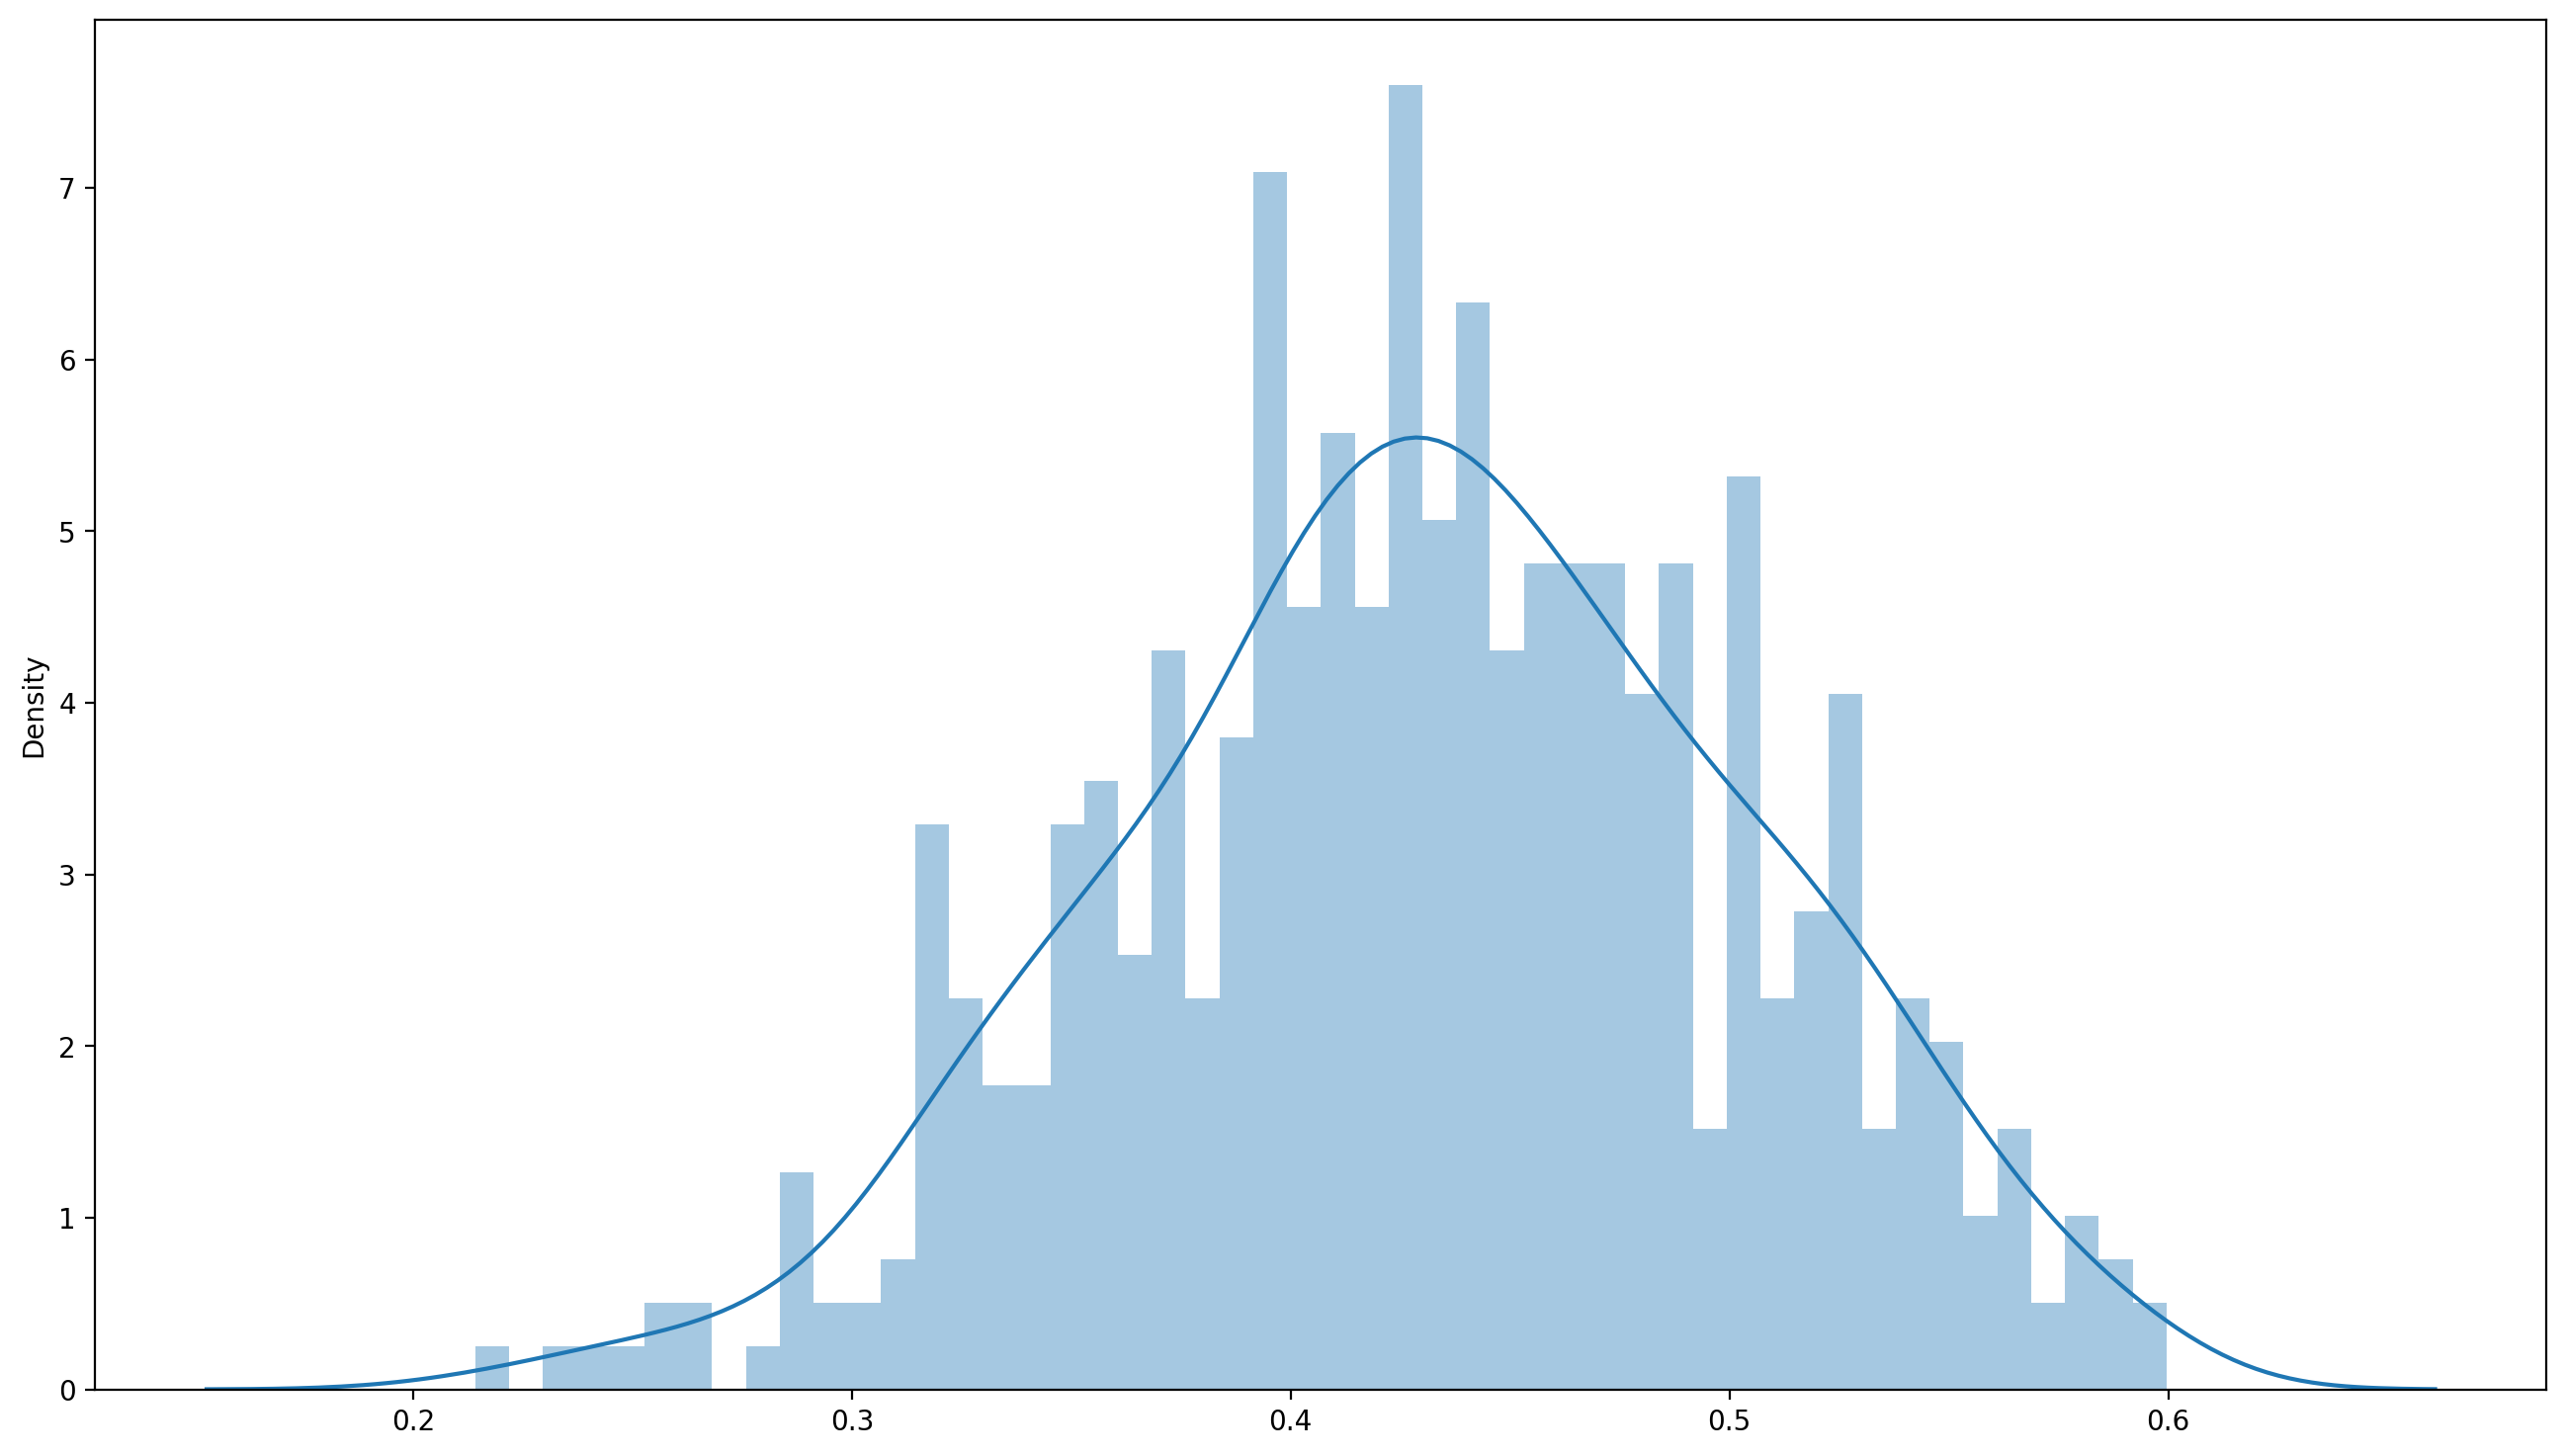

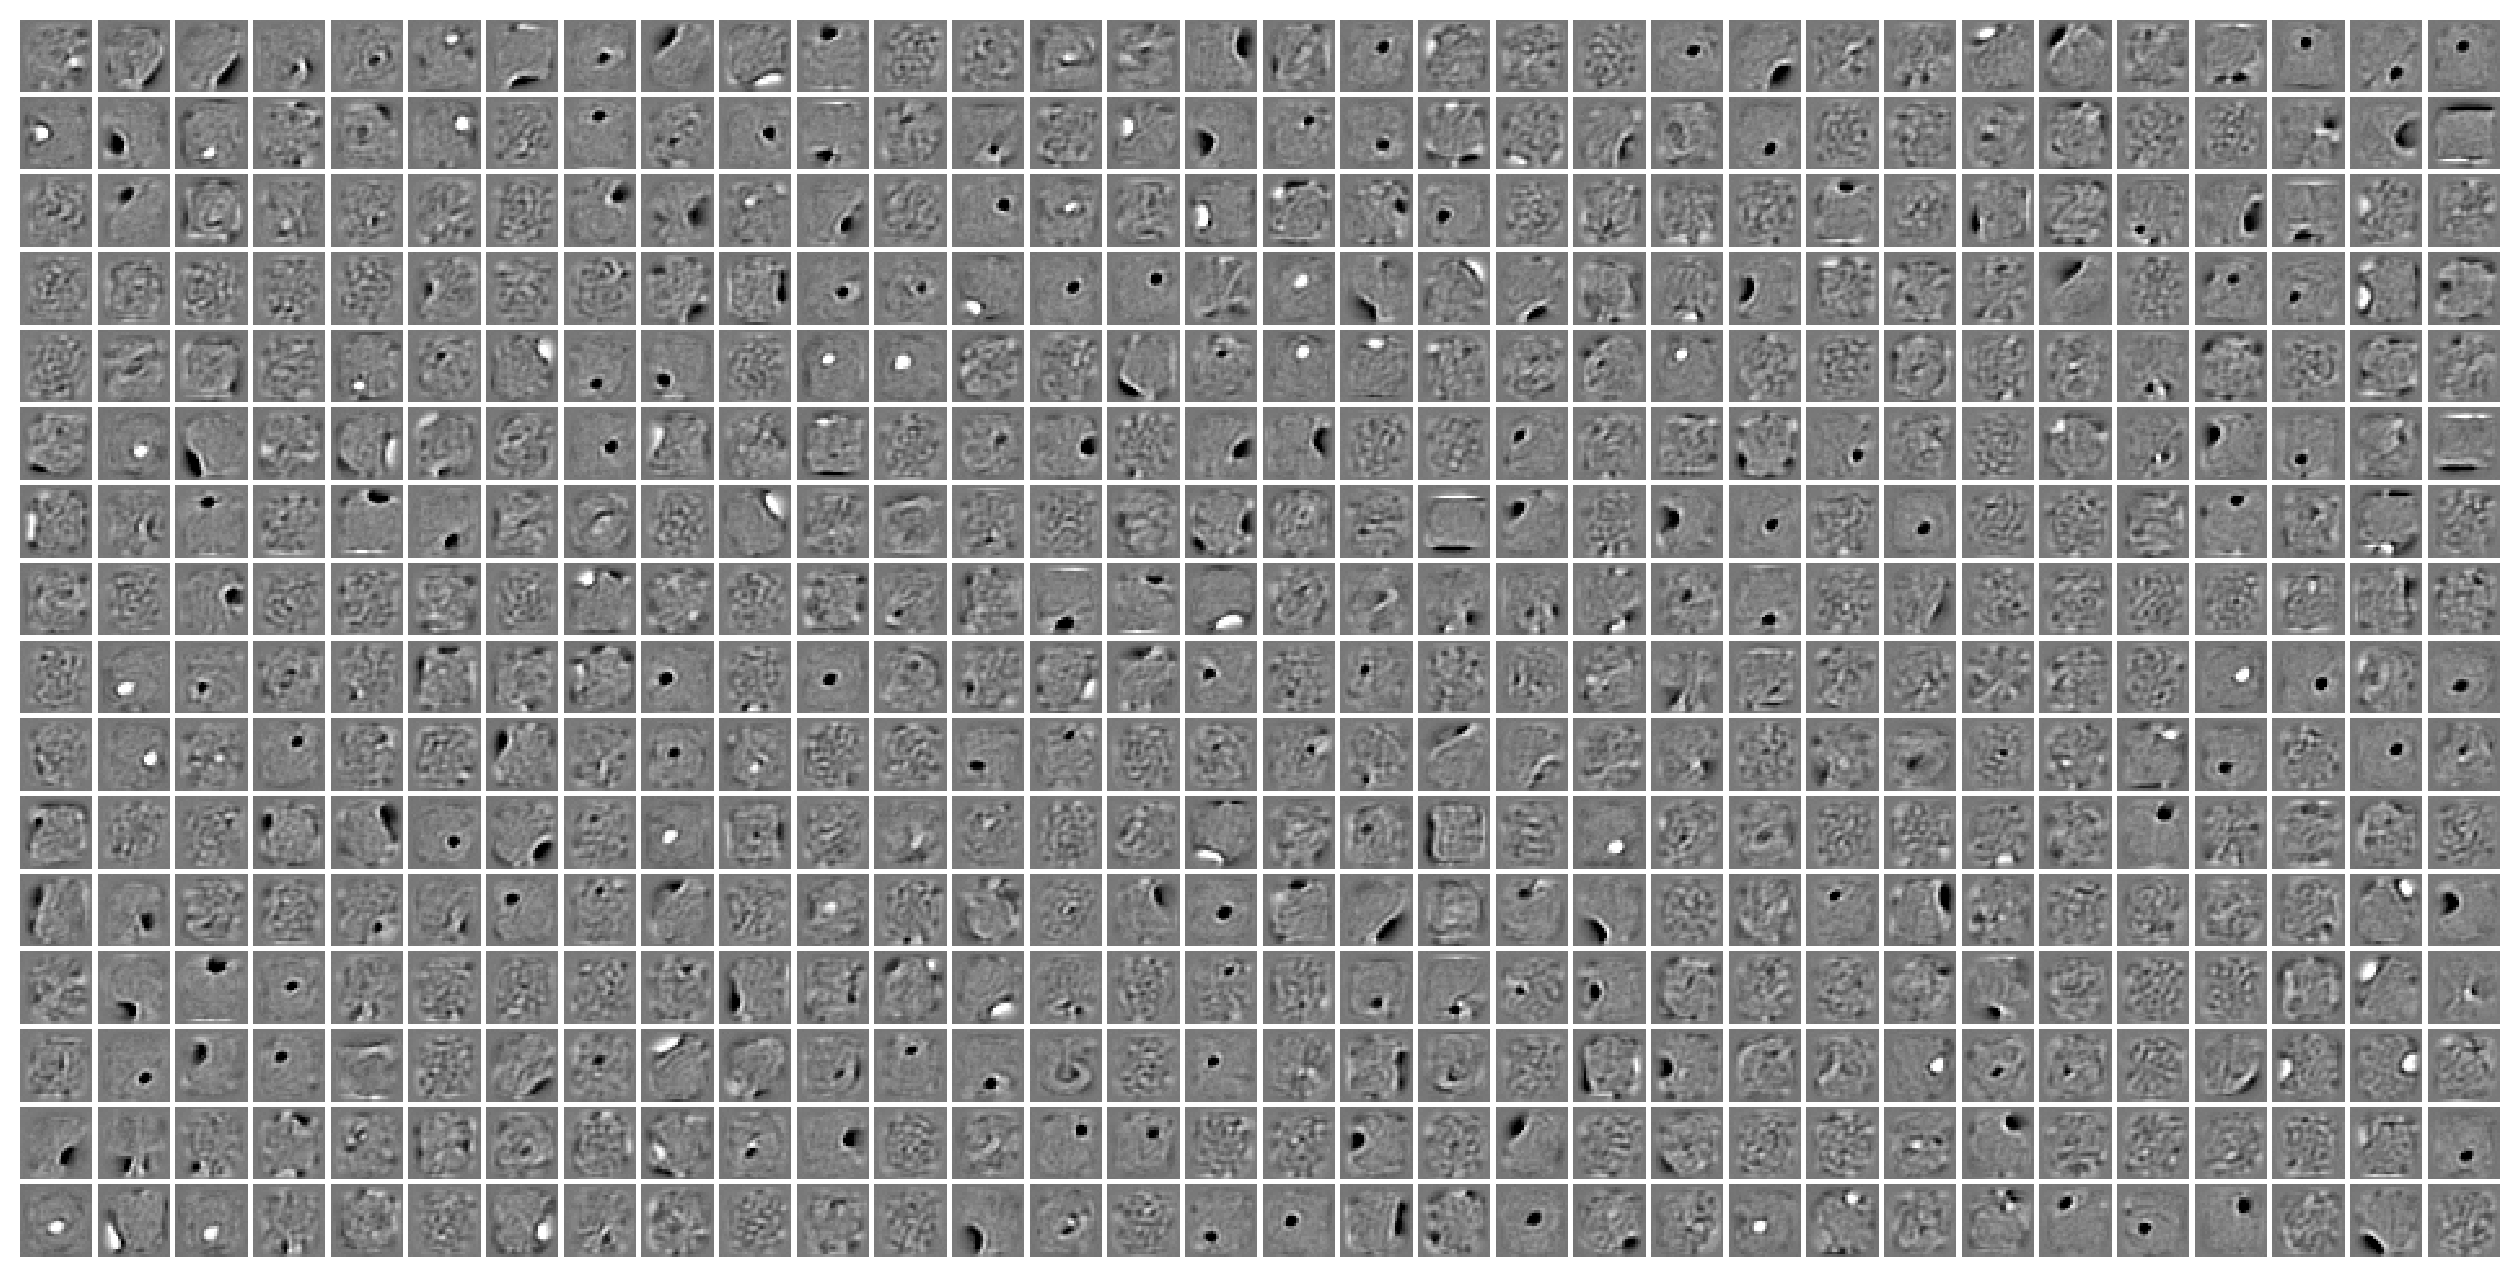

In [69]:
# Plotting mean hidden activations
activations = feed_forward(rbm.W, mnist_dataset, sigmoid)

mean_activations = np.mean(activations, 1)
sns.distplot(mean_activations, bins=50)

# Displaying RBM filetrs
filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], newshape=(16, -1, 28, 28))
filters = np.clip(filters, -1.0, 1.0)

img = tiles(filters)
plt.matshow(img, cmap='gray', interpolation='none')
plt.axis('off')
plt.show()

In [70]:
activations.shape

(512, 513)

In [71]:
len(activations)

512